# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

In [2]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
...,...,...,...,...,...,...,...,...
159,29.0,Female,"27.500,00",High School Diploma,Single,0,Rented,Low
160,34.0,Male,"47.500,00",Associate's Degree,Single,0,Rented,Average
161,39.0,Female,"62.500,00",Bachelor's Degree,Married,2,Owned,High
162,44.0,Male,"87.500,00",Master's Degree,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [3]:
df.dtypes

Age                   float64
Gender                 object
Income                 object
Education              object
Marital Status         object
Number of Children      int64
Home Ownership         object
Credit Score           object
dtype: object

In [4]:

df['Credit Score'] = df['Credit Score'].replace({'High' : 2, 'Average' : 1, 'Low' : 0})

df['Credit Score'] = df['Credit Score'].astype(int)

C:\Users\samco\AppData\Local\Temp\ipykernel_9672\882336394.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Credit Score'] = df['Credit Score'].replace({'High' : 2, 'Average' : 1, 'Low' : 0})


**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [5]:
df.isnull().sum()*100/len(df)

Age                   20.731707
Gender                 0.000000
Income                 0.000000
Education              0.000000
Marital Status         0.000000
Number of Children     0.000000
Home Ownership         0.000000
Credit Score           0.000000
dtype: float64

In [6]:
df['Age'].describe()

count    130.000000
mean      37.507692
std        8.500110
min       25.000000
25%       30.000000
50%       36.000000
75%       45.000000
max       53.000000
Name: Age, dtype: float64

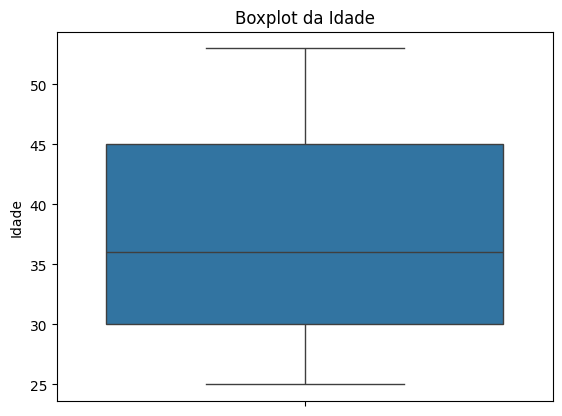

In [7]:
sns.boxplot(data=df, y='Age')
plt.title('Boxplot da Idade')
plt.ylabel('Idade')
plt.show()

In [8]:
df['Age'].fillna(df['Age'].median(), inplace=True)

C:\Users\samco\AppData\Local\Temp\ipykernel_9672\1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [9]:
df['Age'] = df['Age'].astype(int)

In [10]:
df['Income'] = df['Income'].str.replace('.','', regex= False) 
df['Income'] = df['Income'].str.replace(',','.', regex= False) 

In [11]:
df['Income'].head()

0     50000.00
1    100000.00
2     75000.00
3    125000.00
4    100000.00
Name: Income, dtype: object

In [12]:
df['Income'] = df['Income'].astype(float)

**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [13]:
df['Gender'].unique()
df['Education'].unique()
df['Home Ownership'].unique()
df['Marital Status'].unique()

array(['Single', 'Married'], dtype=object)

# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [14]:
df.describe()

,Age,Income,Number of Children,Credit Score
count,164.000000,164.000000,164.000000,164.000000
mean,37.195122,83765.243902,0.652439,1.597561
std,7.586619,32457.306728,0.883346,0.652692
min,25.000000,25000.000000,0.000000,0.000000
25%,31.750000,57500.000000,0.000000,1.000000
50%,36.000000,83750.000000,0.000000,2.000000
75%,43.000000,105000.000000,1.000000,2.000000
max,53.000000,162500.000000,3.000000,2.000000


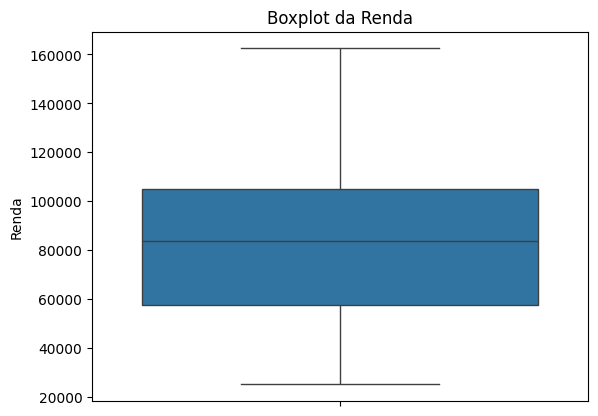

In [15]:
sns.boxplot(data=df, y='Income')
plt.title('Boxplot da Renda')
plt.ylabel('Renda')
plt.show()

# A princípio olhando pelo describe, o desvio padrão está muito alto(o que não faz sentido pois a média está muito próxima à mediana) e ao plotar o gráfico de boxplot, não há indícios de outliers.

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

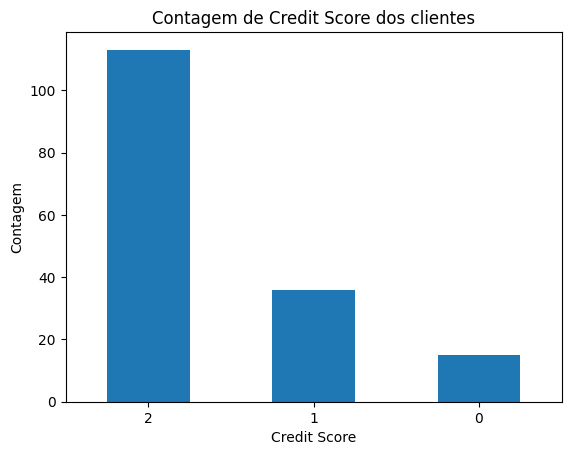

In [16]:
contagem = df['Credit Score'].value_counts()


contagem.plot(kind='bar')

plt.title('Contagem de Credit Score dos clientes')
plt.xlabel('Credit Score')
plt.ylabel('Contagem')
plt.xticks(rotation=0)
plt.show()


C:\Users\samco\AppData\Local\Temp\ipykernel_9672\2388433935.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 5, f'{porcentagem[i]:.2f}%', ha='center')


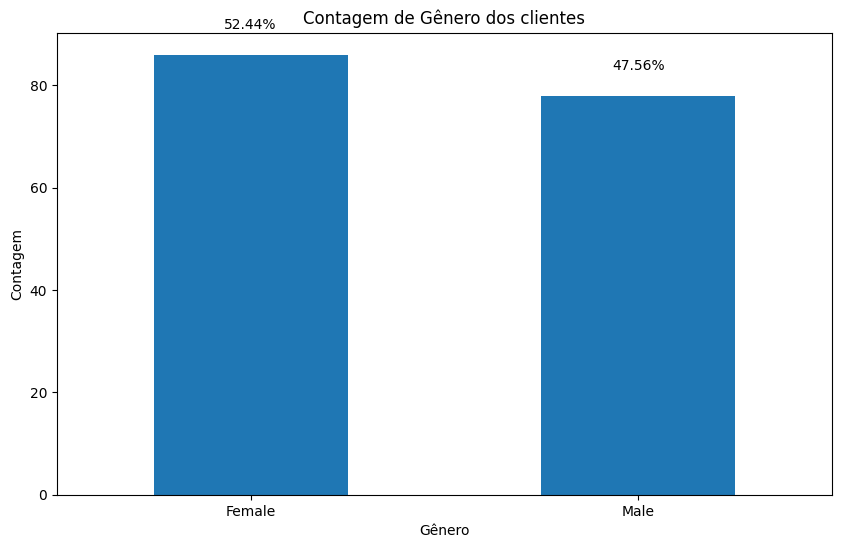

In [17]:
contagem = df['Gender'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100
plt.figure(figsize=(10, 6))
ax = contagem.plot(kind='bar')

for i, v in enumerate(contagem):
    ax.text(i, v + 5, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Contagem de Gênero dos clientes')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.xticks(rotation=0)
plt.show()


C:\Users\samco\AppData\Local\Temp\ipykernel_9672\2366804149.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 5, f'{porcentagem[i]:.2f}%', ha='center')


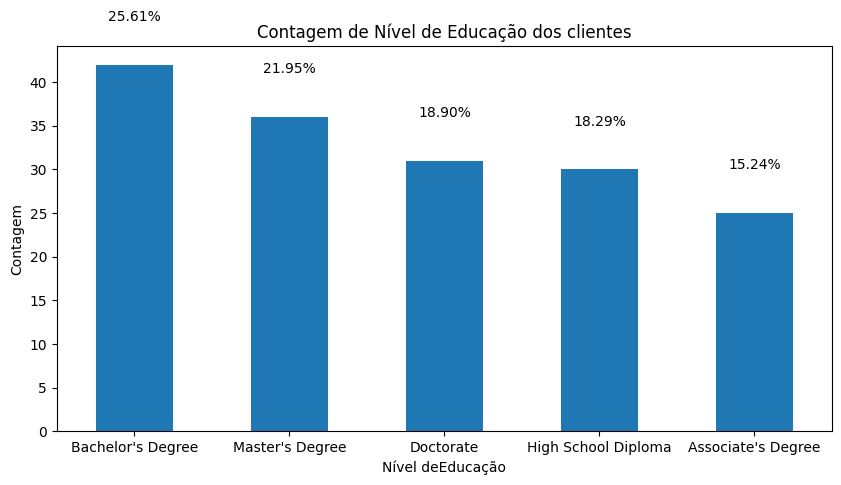

In [18]:
contagem = df['Education'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100
plt.figure(figsize=(10, 5))
ax = contagem.plot(kind='bar')

for i, v in enumerate(contagem):
    ax.text(i, v + 5, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Contagem de Nível de Educação dos clientes')
plt.xlabel('Nível deEducação')
plt.ylabel('Contagem')
plt.xticks(rotation=0)
plt.show()

C:\Users\samco\AppData\Local\Temp\ipykernel_9672\3849419092.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 5, f'{porcentagem[i]:.2f}%', ha='center')


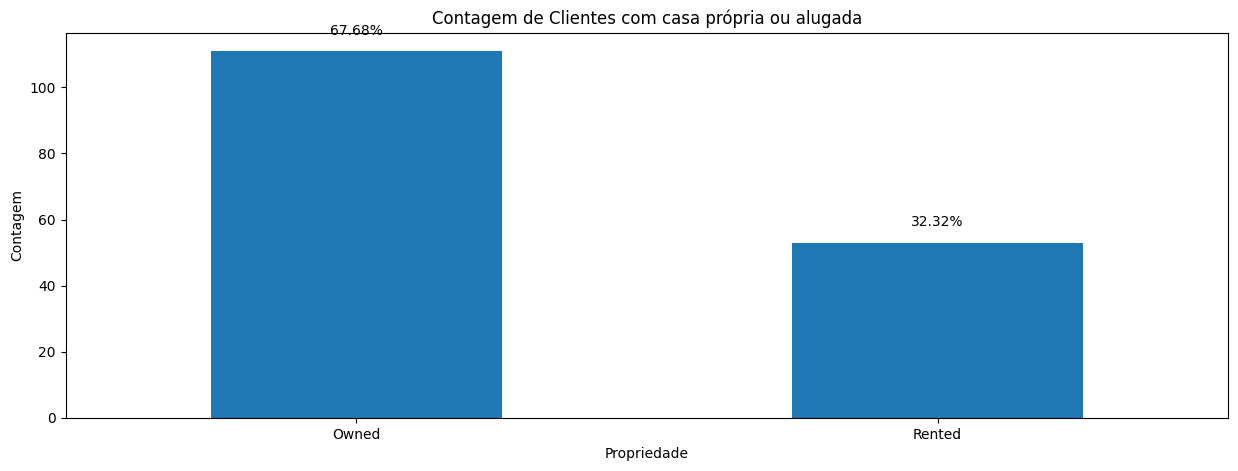

In [19]:
contagem = df['Home Ownership'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100
plt.figure(figsize=(15, 5))
ax = contagem.plot(kind='bar')

for i, v in enumerate(contagem):
    ax.text(i, v + 5, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Contagem de Clientes com casa própria ou alugada')
plt.xlabel('Propriedade')
plt.ylabel('Contagem')
plt.xticks(rotation=0)
plt.show()

C:\Users\samco\AppData\Local\Temp\ipykernel_9672\9055427.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 5, f'{porcentagem[i]:.2f}%', ha='center')


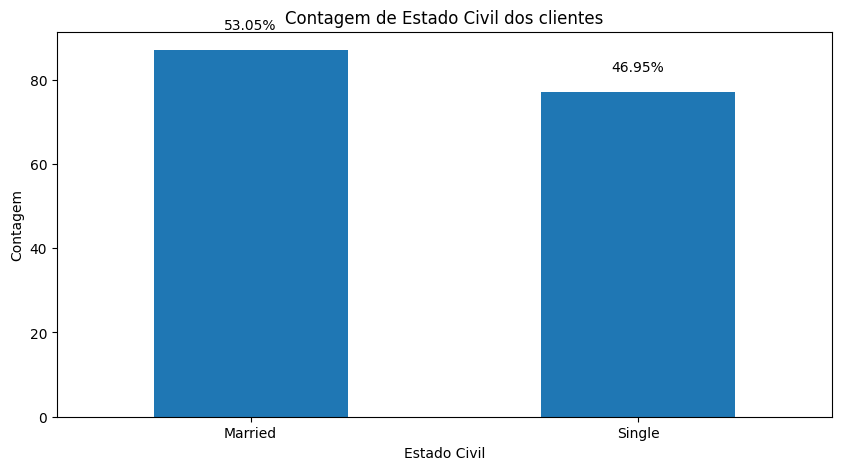

In [20]:
contagem = df['Marital Status'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100
plt.figure(figsize=(10, 5))
ax = contagem.plot(kind='bar')

for i, v in enumerate(contagem):
    ax.text(i, v + 5, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Contagem de Estado Civil dos clientes')
plt.xlabel('Estado Civil')
plt.ylabel('Contagem')
plt.xticks(rotation=0)
plt.show()

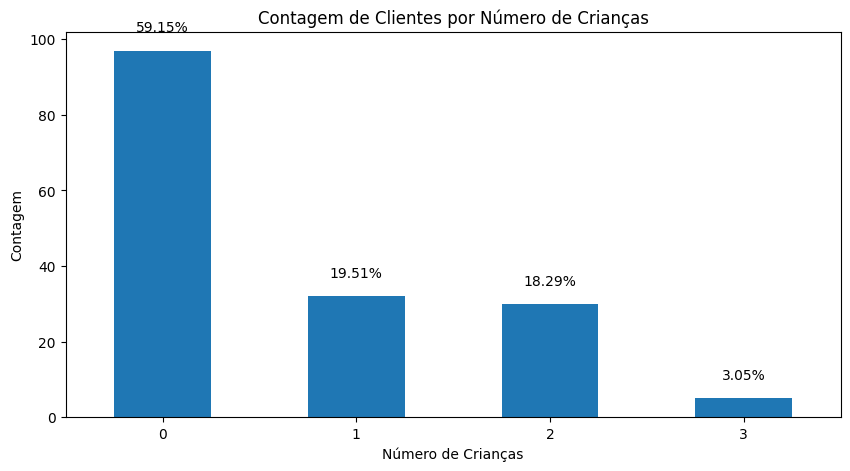

In [21]:
contagem = df['Number of Children'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100
plt.figure(figsize=(10, 5))
ax = contagem.plot(kind='bar')

for i, v in enumerate(contagem):
    ax.text(i, v + 5, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Contagem de Clientes por Número de Crianças')
plt.xlabel('Número de Crianças')
plt.ylabel('Contagem')
plt.xticks(rotation=0)
plt.show()

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

In [22]:
# Não

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*Existe relação entre a idade e o status civil?
    Os clientes mais velhos tem maior tendência a estarem casados

*Qual a relação entre o score de crédito e o nível de escolaridade?
    É perceptível que pssoas com maior nível de escolaridade têm um credit score maior, mas não é um fator decisivo.

*O salário parece influenciar na idade?
    Aparentemente ocorre um aumento consideravel na média de salário de pessoas de 30, 40 e 50 anos

*O salário parece influenciar no Score de Crédito?
    Em média sim, quanto maior o salário maior o score

*Clientes com casa própria tendem a ter um score mais alto?
    Completamente, em sua grande maioria clientes com casa própria possuem o nível de score mais alto. Não há cliente que tenha casa própria com o nível de score baixo.


In [23]:
df_grouped = df.groupby(['Age', 'Marital Status']).size().reset_index(name='count') 
total_por_genero = df_grouped.groupby('Marital Status')['count'].transform('sum')

df_grouped['percentage'] = df_grouped['count'] / total_por_genero * 100

fig = px.bar(df_grouped, x='Age', y='percentage', color='Marital Status')

fig.update_layout(
    title='Distribuição de Idade por Estado Civil', 
    xaxis_title='Idade', 
    yaxis_title='Porcentagem')

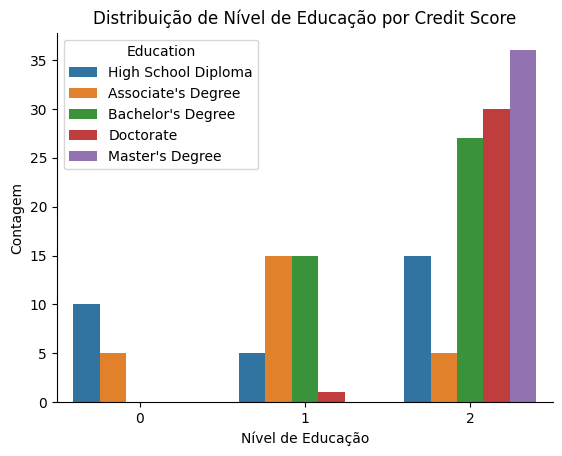

In [24]:
sns.countplot(x='Credit Score', hue='Education', data=df)
plt.title('Distribuição de Nível de Educação por Credit Score')
plt.xlabel('Nível de Educação')
plt.ylabel('Contagem')
sns.despine()
plt.show()

Text(0, 0.5, 'Média de Renda')

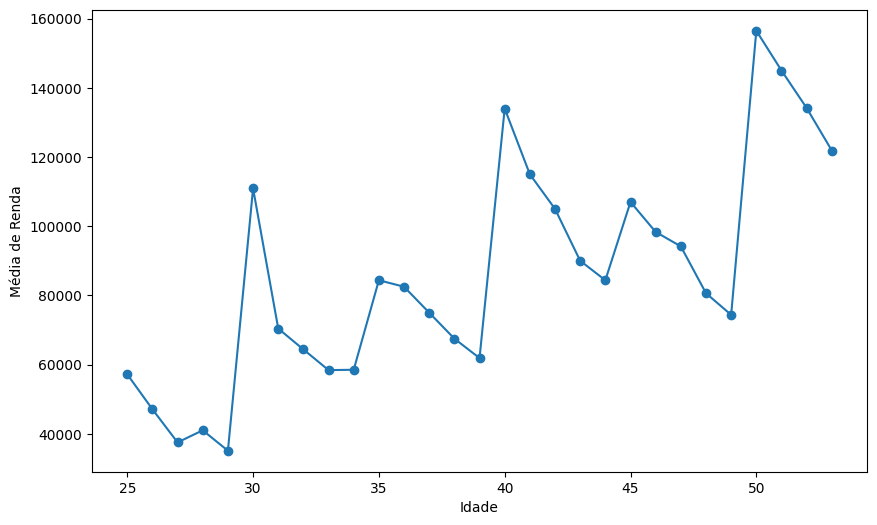

In [25]:

media_salario_por_idade = df.groupby('Age')['Income'].mean() 

media_salario_por_idade = media_salario_por_idade.sort_index() 

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(media_salario_por_idade.index, media_salario_por_idade.values, marker='o')
ax1.set_xlabel('Idade')
ax1.set_ylabel('Média de Renda')

<BarContainer object of 3 artists>

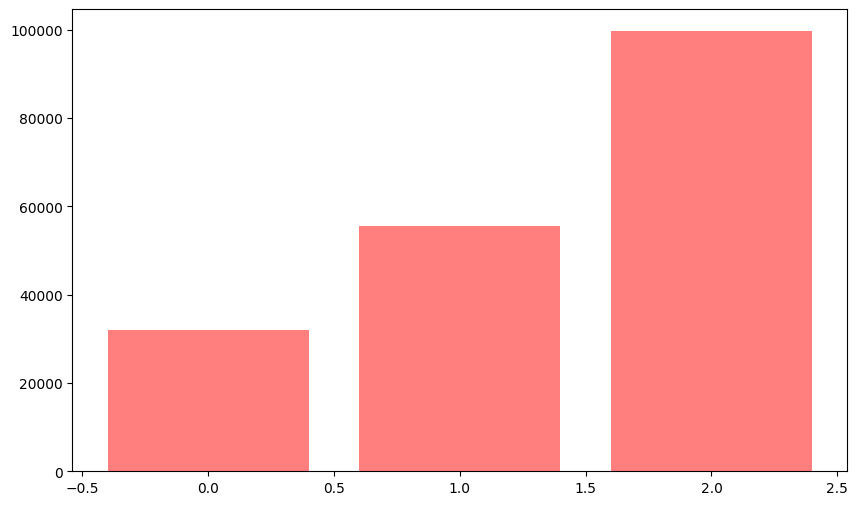

In [26]:
media_salario_por_credito = df.groupby('Credit Score')['Income'].mean()
fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.bar(media_salario_por_credito.index, media_salario_por_credito, color='red', alpha=0.5, label='Média do Salário por Score de Crédito')

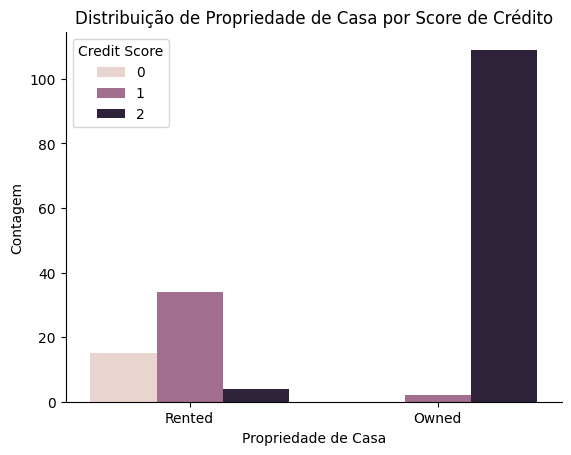

In [27]:
sns.countplot(x='Home Ownership', hue='Credit Score', data=df)
plt.title('Distribuição de Propriedade de Casa por Score de Crédito')
plt.xlabel('Propriedade de Casa')
plt.ylabel('Contagem')
sns.despine()
plt.show()

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

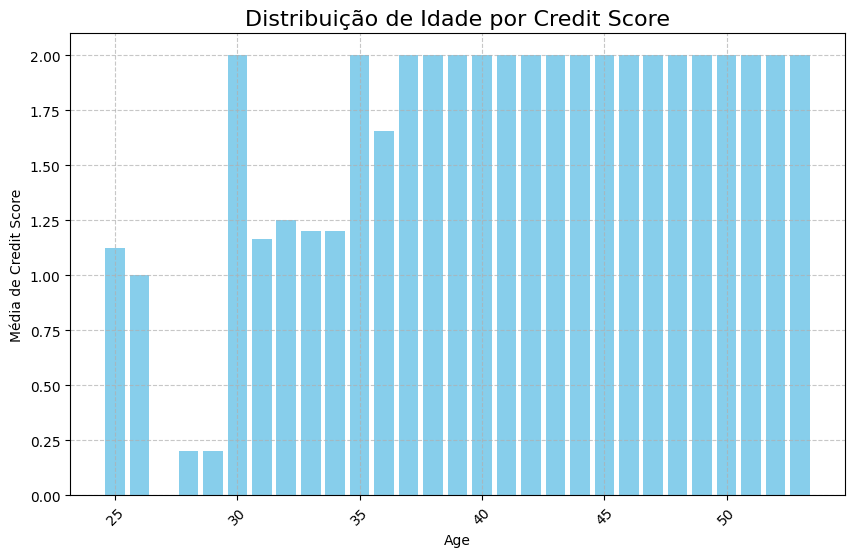

In [28]:
# A idade influencia no credit score?


plt.figure(figsize=(10, 6)) 
idade_por_credito = df.groupby('Age')['Credit Score'].mean().sort_values() 
plt.bar(idade_por_credito.index, idade_por_credito, color='skyblue') 
plt.title('Distribuição de Idade por Credit Score', fontsize=16) 
plt.xlabel('Age')
plt.ylabel('Média de Credit Score')
plt.xticks(rotation=45) 
plt.grid(True, linestyle='--', alpha=0.7) 
plt.show()

# Pessoas maiores de 37 anos possuem o credit score máximo.

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

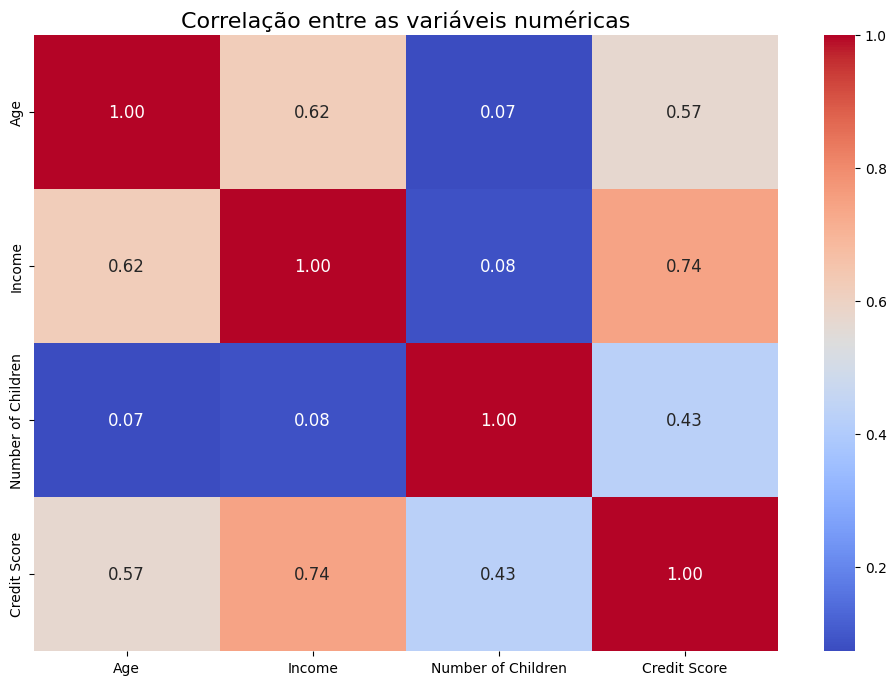

In [29]:
correlation = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 12})
plt.title('Correlação entre as variáveis numéricas', fontsize=16)
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

In [30]:
# - O salário e o credit score possuem uma correlação positiva interessante, e realmente faz sentido, pessoas com um salário maior tem mais condições de pagar suas contas em dia, oq eu facilita uma conceção de credito.
# - Outra correlação interessante que já haviamos notado atraves da analise bivariada, é a correlação entre salário e idade, onde pessoas de maior idade possuem um salário maior.
# - Podemos adicionar também aqui a relação entra idade e credit score, que também verificamos através de análise bivarida que possuem uma relação positiva, quanto maior a idade, maior o credit score. 
    # Essa relação eu já discordo um pouco, pois pessoas de idade mais avançada estão mais sujeitas ao desgaste do tempo, e não é possível prever quando esse tempo irá acabar, 
    # então conceder possibilidades melhores de aquisição de credito para pessoas de muita idade não faz tanto sentido.
# No mais percebo correlações mais frias/fracas entre as outras variáveis.

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [31]:
df.head()

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25,Female,50000.0,Bachelor's Degree,Single,0,Rented,2
1,30,Male,100000.0,Master's Degree,Married,2,Owned,2
2,35,Female,75000.0,Doctorate,Married,1,Owned,2
3,40,Male,125000.0,High School Diploma,Single,0,Owned,2
4,45,Female,100000.0,Bachelor's Degree,Married,3,Owned,2


In [32]:
label = LabelEncoder()

df['Gender'] = label.fit_transform(df['Gender'])
df['Marital Status'] = label.fit_transform(df['Marital Status'])
df['Home Ownership'] = label.fit_transform(df['Home Ownership'])

#df = pd.get_dummies(df, columns=['Education'], prefix='Edu', drop_first=True)

# Não acho que o one-hot encode seja o melhor método de codificação para a variável Education, pois ela possui uma ordem natural, tem uma hierarquia.
# Então tomei liberdade de utilizar o método de classificação manual. Como o label enconder não classifica corretamente por nível hierarquico dentro da variável como deveria ser.

education_ordem = {'High School Diploma': 0, "Associate's Degree": 1, "Bachelor's Degree": 2, "Doctorate": 3, "Master's Degree": 4}
df['Education'] = df['Education'].map(education_ordem) 




df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25,0,50000.0,2,1,0,1,2
1,30,1,100000.0,4,0,2,0,2
2,35,0,75000.0,3,0,1,0,2
3,40,1,125000.0,0,1,0,0,2
4,45,0,100000.0,2,0,3,0,2
5,50,1,150000.0,4,0,0,0,2
6,26,0,40000.0,1,1,0,1,1
7,31,1,60000.0,2,1,0,1,1
8,36,0,80000.0,4,0,2,0,2
9,36,1,105000.0,3,1,0,0,2


**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

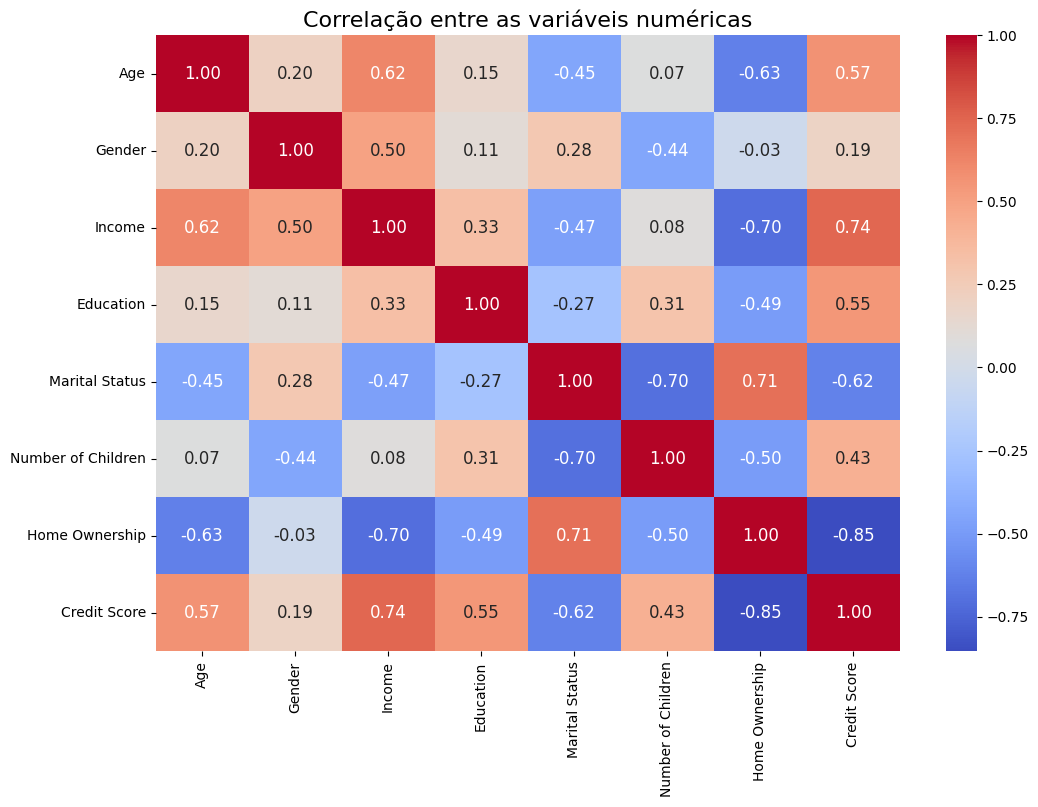

In [33]:
correlation = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 12})
plt.title('Correlação entre as variáveis numéricas', fontsize=16)
plt.show()

# Como o label encoder definiu quem tem casa própria como 0, é possível verificar uma forte correlação negativa entra Home ownership e credit score, ou seja, quem possue casa própria goza do melhor credit score.
# Encontramos também uma correlação com o nível de educação, onde quanto maior o nível de educação, melhor o credit score, o que também faz sentido, pois pessoas com um nível de educação mais elevado tem mais chances de conseguir um emprego melhor remunerado, e isso facilita a aquisição de crédito.


**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [34]:
X= df.drop('Credit Score', axis=1)
y = df['Credit Score']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [36]:
print("X train shape:", X_train.shape)
print("y train shape:", y_train.shape)
print("X test shape:", X_test.shape)
print("y test shape:", y_test.shape)

X train shape: (123, 7)
y train shape: (123,)
X test shape: (41, 7)
y test shape: (41,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

Text(0.5, 1.0, 'Contagem de Credit Score dos clientes')

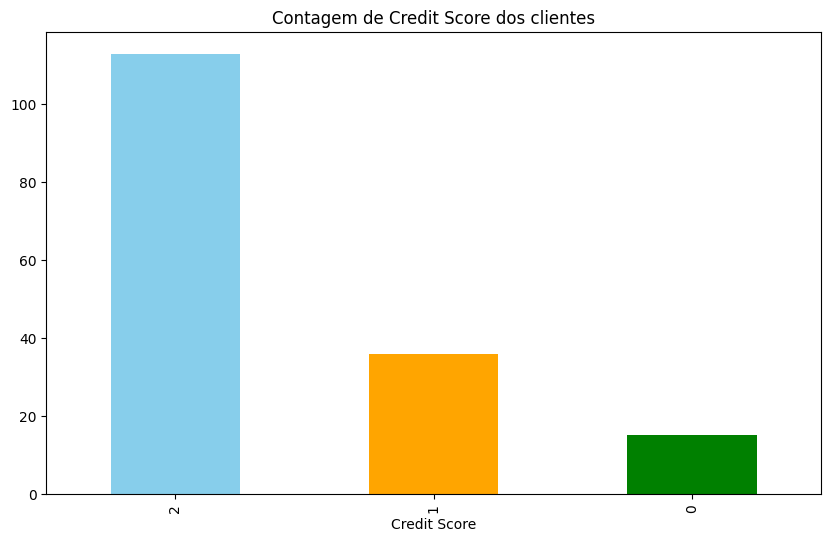

In [37]:
credit_counts = df['Credit Score'].value_counts()
plt.figure(figsize=(10, 6))
credit_counts.plot(kind='bar', color=['skyblue','orange','green'])
plt.title('Contagem de Credit Score dos clientes')

# Totalmente desbalanceado, o número de pessoas com high score é muito maior do que os outros, mais da metade de base.

In [38]:
print((df['Credit Score'].value_counts(normalize=True) * 100))

Credit Score
2    68.902439
1    21.951220
0     9.146341
Name: proportion, dtype: float64


**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [39]:
from imblearn.over_sampling import SMOTE

# Criar uma instancia do SMOTE
smote = SMOTE(random_state=42)

# Aplicar o SMOTE aos dados de treinamento (x_train e y_train)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Aplicar o SMOTE aos dados de teste (x_test e y_test)
X_test_balanced, y_test_balanced = smote.fit_resample(X_test, y_test)

# Verificar a distribuição das classes após o balanceamento
print('Distribuição das classes após o balanceamento:')
print(y_train_balanced.value_counts())
print(y_test_balanced.value_counts())

Distribuição das classes após o balanceamento:
Credit Score
1    84
0    84
2    84
Name: count, dtype: int64
Credit Score
1    29
2    29
0    29
Name: count, dtype: int64


In [40]:
y_test_balanced

0     1
1     2
2     1
3     2
4     2
     ..
82    1
83    1
84    1
85    1
86    1
Name: Credit Score, Length: 87, dtype: int64

In [41]:
X_train_balanced.to_csv('X_train_balanced.csv', index=False)
X_test_balanced.to_csv('X_test_balanced.csv', index=False)
y_train_balanced.to_csv('y_train_balanced.csv', index=False)
y_test_balanced.to_csv('y_test_balanced.csv', index=False)